<a href="https://colab.research.google.com/github/E-tech-coder/DataScienceCapstoneProject/blob/Michi/FeatureEngineering%2BRandomForest_v10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/E-tech-coder/DataScienceCapstoneProject.git

Cloning into 'DataScienceCapstoneProject'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 186 (delta 70), reused 20 (delta 20), pack-reused 88 (from 1)
Receiving objects: 100% (186/186), 1.53 MiB | 6.26 MiB/s, done.
Resolving deltas: 100% (103/103), done.


In [2]:
%cd DataScienceCapstoneProject
!git checkout Michi

/content/DataScienceCapstoneProject
Branch 'Michi' set up to track remote branch 'Michi' from 'origin'.
Switched to a new branch 'Michi'


In [3]:
ls

Data_Exploration.ipynb
data_exploration_v2.ipynb
department-v2.csv
df_profiles_cleansed
FeatureEngineering+RandomForest.ipynb
linkedin-cvs-annotated.json
linkedin-cvs-not-annotated.json
linkedin-cvs-not-annotated-to-be-predicted
linkedin_experience_annotated.csv
rulebasedmodel_michi_done.ipynb
RuleBasedModel-Michi.ipynb
seniority-v2.csv


**EXTENDED FEATURE ENGINEERING & RANDOM FOREST MODEL**

Due to previously identified inconsistencies, the existing feature engineering and the random forest model were revised and specifically expanded. The key adjustment was the removal of the ACTIVE status from the training process in order to increase the available data base and train the model more robustly. In addition, multilingual word embeddings were integrated as an extension of the feature representation, and a clearly structured, reproducible pipeline for training and inference was established.

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("df_profiles_cleansed")
df.sample(10)

,organization,position,startDate,endDate,status,department,seniority,person_id,job_count,job_duration_years
1401,Winback GmbH,Beratung/Vertrieb WinBack GmbH,2023-05,2024-10,INACTIVE,Consulting,Professional,322,8,1.421918
354,Stadsavonturen,Regisseur en scriptschrijver,1998-01,2000-01,INACTIVE,Other,Professional,80,16,2.000000
66,tdc,inspektør,2023-01,2025-12,ACTIVE,Other,Professional,19,1,2.917808
493,Siemens Logistics & Assembly / Siemens Dematic AG,Segmentleiter “Distributionslogistik / IT Appl...,2001-01,2005-01,INACTIVE,Information Technology,Lead,117,10,4.002740
2311,DFMG Deutsche Funkturm GmbH,Leiter Personal und Recht,2023-01,2025-12,ACTIVE,Human Resources,Lead,540,1,2.917808
549,LayTec,Manager Purchasing,2023-01,2025-12,ACTIVE,Purchasing,Professional,130,1,2.917808
1984,RESTAURANT L'ARCHIPEL,Chef de rang,2023-02,2024-02,INACTIVE,Other,Professional,457,8,1.000000
289,Austria Wirtschaftsservice,Head of Verified Social Enterprise - Label,2022-08,2024-02,INACTIVE,Other,Lead,72,9,1.504110
421,Stadt Zug,Departementssekretär Finanz,2005-09,2025-12,ACTIVE,Other,Professional,101,7,20.263014
1340,Yatego GmbH,Head of Account Management,2013-04,2025-12,ACTIVE,Sales,Lead,307,4,12.676712


In [5]:
#Separate raw data
ID_COLS = ["person_id"]

TARGET_COLS = [
    "seniority",
    "department"
]

JOB_COLS = [
    "organization",
    "position",
    "startDate",
    "endDate",
    "status",
    "job_count",
    "job_duration_years"
]

In [6]:
#split by person
profiles = df["person_id"].unique()

In [7]:
#Stratify according to highest seniority per person
SENIORITY_RANK = {
    "Junior": 1,
    "Professional": 2,
    "Senior": 3,
    "Lead": 4,
    "Management": 5,
    "Director": 6
}

sen_rank_per_person = (
    df.assign(seniority_rank=df["seniority"].map(SENIORITY_RANK))
      .groupby("person_id")["seniority_rank"]
      .max()
)

In [8]:
#map rank back to label for stratify
rank_to_label = {v: k for k, v in SENIORITY_RANK.items()}
seniority_label_per_person = sen_rank_per_person.map(rank_to_label)

In [9]:
#train test split (80/20) for person_id
from sklearn.model_selection import train_test_split

train_profiles, test_profiles = train_test_split(
    profiles,
    test_size=0.2,
    random_state= 0,
    stratify=seniority_label_per_person.loc[profiles]
)

df_train = df[df["person_id"].isin(train_profiles)].copy()
df_test  = df[df["person_id"].isin(test_profiles)].copy()

print("Train persons:", df_train["person_id"].nunique(), "rows:", len(df_train))
print("Test persons:",  df_test["person_id"].nunique(),  "rows:", len(df_test))

Train persons: 485 rows: 2055
Test persons: 122 rows: 560


Feature Engineering

In [10]:
#text normalization
def safe_lower(x):
    return x.lower() if isinstance(x, str) else ""

In [11]:
#adding title statistical features
def add_title_stats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    titles = df["position"].apply(safe_lower)

    df["title_length"] = titles.str.len()
    df["title_word_count"] = titles.str.split().apply(len)

    return df

In [12]:
#adding keyword count features
SENIORITY_KEYWORDS = {
    "management": ["ceo","cfo","cto","cmo","chief","vice","president","owner","gesellschafter","founder","cofounder","co-founder","prokurist","prokuristin","unternehmensinhaber","gesch"],
    "director": ["director","global","international","dach"],
    "lead": ["lead","leitung","leiter","head"],
    "senior": ["senior", "sr"],
    "junior": ["intern","junior","trainee","student","werkstudent","referent","assistent","auszubild"],
    "professional": ["analyst","sachbearbeiter"]
}

DEPARTMENT_KEYWORDS = {
    "administrative": ["assistentin","assistenz","assistent","office","assistant","sekret"],
    "business_development": ["business","development","bd"],
    "consulting": ["consultant","berater","sap","dynamics","erp"],
    "customer_support": ["support","customer","supporter"],
    "information_technology": ["software","developer","engineer","architect","devops","cloud","data scientist","data engineer","network","systems administrator","administrator","it"],
    "human_resources": ["human","resources","ressource"],
    "marketing": ["marketing","communication","communications","kommunikation","messe","event"],
    "project_management": ["project","projektleiter","projektmanager","projektmanagement","projekt","projektleitung","projects"],
    "purchasing": ["einkauf","purchas","eink"],
    "sales": ["sales","vertrieb","vertriebsleiter","salesforce"]
}

In [13]:
def add_keyword_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    titles = df["position"].apply(safe_lower)

    # Seniority keyword counts
    for sen_group, keywords in SENIORITY_KEYWORDS.items():
        df[f"{sen_group}_keyword_count"] = titles.apply(
            lambda x: sum(k in x for k in keywords)
        )

    # Department keyword counts
    for dept, keywords in DEPARTMENT_KEYWORDS.items():
        df[f"{dept}_keyword_count"] = titles.apply(
            lambda x: sum(k in x for k in keywords)
        )

    return df

In [14]:
train_fe = df_train.copy()
test_fe  = df_test.copy()

train_fe = add_title_stats(train_fe)
train_fe = add_keyword_features(train_fe)

test_fe = add_title_stats(test_fe)
test_fe = add_keyword_features(test_fe)

In [15]:
#final feature list
FEATURE_COLS = [
    # Karriere
    "job_count",
    "job_duration_years",

    # Titel-statistics
    "title_length",
    "title_word_count",

    # Keywords
    "management_keyword_count",
    "director_keyword_count",
    "lead_keyword_count",
    "senior_keyword_count",
    "junior_keyword_count",
    "professional_keyword_count",
    "administrative_keyword_count",
    "business_development_keyword_count",
    "consulting_keyword_count",
    "customer_support_keyword_count",
    "information_technology_keyword_count",
    "human_resources_keyword_count",
    "marketing_keyword_count",
    "project_management_keyword_count",
    "purchasing_keyword_count",
    "sales_keyword_count"
]

In [16]:
#check
train_fe[FEATURE_COLS].isna().sum()

,0
job_count,0
job_duration_years,0
title_length,0
title_word_count,0
management_keyword_count,0
director_keyword_count,0
lead_keyword_count,0
senior_keyword_count,0
junior_keyword_count,0
professional_keyword_count,0


Setting up x and y -> same x for seniority and for department

In [17]:
X_train = train_fe[FEATURE_COLS]
X_test  = test_fe[FEATURE_COLS]

#seniority
y_train_seniority = train_fe["seniority"]
y_test_seniority  = test_fe["seniority"]

In [18]:
#department
y_train_department = train_fe["department"]
y_test_department  = test_fe["department"]

In [19]:
print(X_train.shape, y_train_seniority.shape)
print(X_test.shape, y_test_seniority.shape)

(2055, 20) (2055,)
(560, 20) (560,)


In [20]:
X_train.head()


,job_count,job_duration_years,title_length,title_word_count,management_keyword_count,director_keyword_count,lead_keyword_count,senior_keyword_count,junior_keyword_count,professional_keyword_count,administrative_keyword_count,business_development_keyword_count,consulting_keyword_count,customer_support_keyword_count,information_technology_keyword_count,human_resources_keyword_count,marketing_keyword_count,project_management_keyword_count,purchasing_keyword_count,sales_keyword_count
14,3,0.915068,23,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15,3,1.917808,28,2,0,0,1,0,0,0,0,0,0,0,1,0,0,2,0,0
16,3,35.693151,26,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
17,7,1.249315,30,4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18,7,1.668493,17,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Random Forest Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier

#initialize and train the Random Forest model for seniority
rf_seniority = RandomForestClassifier(random_state=42)
rf_seniority.fit(X_train, y_train_seniority)

#initialize and train the Random Forest model for department
rf_department = RandomForestClassifier(random_state=42)
rf_department.fit(X_train, y_train_department)

RandomForestClassifier(random_state=42)

Feature Importances for Seniority Model:
                                 Feature  Importance
1                     job_duration_years    0.162177
6                     lead_keyword_count    0.150533
2                           title_length    0.136389
4               management_keyword_count    0.122885
0                              job_count    0.091332
7                   senior_keyword_count    0.086343
3                       title_word_count    0.060794
8                   junior_keyword_count    0.054777
5                 director_keyword_count    0.049613
14  information_technology_keyword_count    0.020764
10          administrative_keyword_count    0.014811
19                   sales_keyword_count    0.008066
12              consulting_keyword_count    0.008040
17      project_management_keyword_count    0.007690
11    business_development_keyword_count    0.006841
16               marketing_keyword_count    0.006104
13        customer_support_keyword_count    0.003859
9    

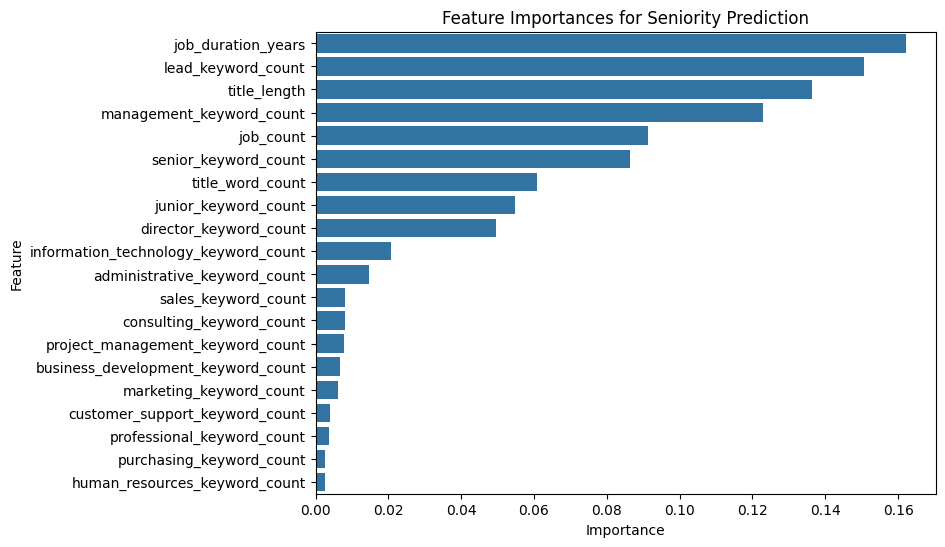

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# get feature importances for seniority model
importance_seniority = rf_seniority.feature_importances_
feature_names = X_train.columns

df_importance_seniority = pd.DataFrame({'Feature': feature_names, 'Importance': importance_seniority})
df_importance_seniority = df_importance_seniority.sort_values(by='Importance', ascending=False)

print("Feature Importances for Seniority Model:")
print(df_importance_seniority)

#visualize feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance_seniority)
plt.title('Feature Importances for Seniority Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [23]:
from sklearn.metrics import classification_report, accuracy_score

#predict on the test set for seniority
y_pred_seniority = rf_seniority.predict(X_test)

#evaluate seniority model
print("Seniority Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_seniority, y_pred_seniority):.4f}")
print(classification_report(y_test_seniority, y_pred_seniority))

#predict on the test set for department
y_pred_department = rf_department.predict(X_test)

#evaluate department model
print("\nDepartment Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_department, y_pred_department):.4f}")
print(classification_report(y_test_department, y_pred_department))

Seniority Model Evaluation:
Accuracy: 0.7946
              precision    recall  f1-score   support

    Director       0.84      0.70      0.76        23
      Junior       0.81      0.66      0.73        53
        Lead       0.88      0.68      0.77        97
  Management       0.79      0.62      0.70        85
Professional       0.76      0.91      0.83       266
      Senior       0.91      0.89      0.90        36

    accuracy                           0.79       560
   macro avg       0.83      0.74      0.78       560
weighted avg       0.80      0.79      0.79       560


Department Model Evaluation:
Accuracy: 0.6393
                        precision    recall  f1-score   support

        Administrative       0.25      0.11      0.15        18
  Business Development       0.62      0.31      0.42        16
            Consulting       0.69      0.58      0.63        43
      Customer Support       0.60      0.50      0.55         6
       Human Resources       1.00      0.06 

**Model Improvements and Limitations**

The use of the full dataset for training had a positive effect on model performance, as it increased the number of available samples per class. This improvement is reflected in higher overall accuracy for both prediction tasks.

Seniority: accuracy increased from 77% to 79%

Department: accuracy increased from 62% to 64%

Despite these gains, certain limitations remain. In particular, the Administrative class in the department prediction task continues to exhibit low performance, with a precision of only 25%, indicating persistent class imbalance and overlapping job title characteristics.

Evaluation and Impovements

**Seniority**

In [24]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_seniority, y_pred_seniority, labels=rf_seniority.classes_)
cm_df = pd.DataFrame(cm, index=rf_seniority.classes_, columns=rf_seniority.classes_)
cm_df

,Director,Junior,Lead,Management,Professional,Senior
Director,16,0,1,3,3,0
Junior,1,35,2,1,14,0
Lead,1,0,66,1,29,0
Management,0,0,1,53,29,2
Professional,0,8,5,9,243,1
Senior,1,0,0,0,3,32


In [25]:
#calculate prediction probabilities for the seniority model
probabilities = rf_seniority.predict_proba(X_test)

#get the confidence for the predicted class (the maximum probability for each sample)
pred_confidence = np.max(probabilities, axis=1)

error_df = test_fe.copy()
error_df["y_true"] = y_test_seniority.values
error_df["y_pred"] = y_pred_seniority
error_df["confidence"] = pred_confidence

#create a new aggregated column for total seniority keyword count
seniority_keyword_cols = [
    "management_keyword_count", "director_keyword_count", "lead_keyword_count",
    "senior_keyword_count", "junior_keyword_count", "professional_keyword_count"
]
error_df["total_seniority_keyword_count"] = error_df[seniority_keyword_cols].sum(axis=1)

error_df[error_df["y_true"] != error_df["y_pred"]][
    ["position", "job_count", "job_duration_years",
     "total_seniority_keyword_count", "y_true", "y_pred", "confidence"]
].sort_values("confidence").head(10)

,position,job_count,job_duration_years,total_seniority_keyword_count,y_true,y_pred,confidence
1550,Assistant Chief Engineer - OBC/DCDC,7,2.917808,1,Junior,Management,0.36
2248,"lian da information technology co., LTD",1,12.342466,0,Professional,Management,0.36
722,Stipendiat,6,0.334247,0,Junior,Lead,0.38
1231,Strategy and Cooperations BMW Motorrad,5,5.002740,0,Professional,Management,0.39
1987,Manutentionnaire entrepôt,8,0.167123,0,Professional,Lead,0.39
1380,Junior HR Services & Resolution specialist wit...,5,0.336986,2,Junior,Professional,0.39
776,Regionalbeauftragter Club Bayern,5,2.002740,0,Lead,Professional,0.41
2479,Chief Opportunities Officer,37,3.002740,1,Management,Professional,0.41
1929,HR Specialist Personnel Development,1,13.594521,0,Professional,Lead,0.42
1549,Global Chief Engineer / Manager - Power Electr...,7,1.249315,2,Lead,Director,0.44


The model performs well for clearly defined seniority levels such as Senior and Professional, while intermediate and managerial levels remain challenging.
Most misclassifications occur between adjacent seniority classes, indicating that the limitations are primarily caused by ambiguous job titles rather than model errors.

**Departments/Domain**




In [26]:
from sklearn.metrics import confusion_matrix

cm_department = confusion_matrix(y_test_department, y_pred_department, labels=rf_department.classes_)
cm_df_department = pd.DataFrame(cm_department, index=rf_department.classes_, columns=rf_department.classes_)
cm_df_department

,Administrative,Business Development,Consulting,Customer Support,Human Resources,Information Technology,Marketing,Other,Project Management,Purchasing,Sales
Administrative,2,0,0,0,0,1,0,14,1,0,0
Business Development,1,5,0,0,0,0,0,10,0,0,0
Consulting,0,1,25,0,0,0,0,14,2,0,1
Customer Support,0,0,0,3,0,1,0,2,0,0,0
Human Resources,1,0,0,0,1,3,0,10,0,1,0
Information Technology,3,0,3,0,0,36,1,30,2,0,1
Marketing,1,0,1,0,0,1,15,17,0,0,1
Other,0,1,5,1,0,20,1,223,3,1,3
Project Management,0,1,1,1,0,0,0,8,18,0,2
Purchasing,0,0,1,0,0,0,0,11,2,7,0


In [27]:
# Calculate prediction probabilities for the department model
probabilities_department = rf_department.predict_proba(X_test)

# Get the confidence for the predicted class
pred_confidence_department = np.max(probabilities_department, axis=1)

error_df_department = test_fe.copy()
error_df_department["y_true"] = y_test_department.values
error_df_department["y_pred"] = y_pred_department
error_df_department["confidence"] = pred_confidence_department

# Create a new aggregated column for total department keyword count
department_keyword_cols = [
    "administrative_keyword_count", "business_development_keyword_count",
    "consulting_keyword_count", "customer_support_keyword_count",
    "information_technology_keyword_count", "human_resources_keyword_count",
    "marketing_keyword_count", "project_management_keyword_count",
    "purchasing_keyword_count", "sales_keyword_count"
]
error_df_department["total_department_keyword_count"] = error_df_department[department_keyword_cols].sum(axis=1)

print("Top 10 misclassified entries for Department Model with lowest confidence:")
error_df_department[error_df_department["y_true"] != error_df_department["y_pred"]][
    ["position", "total_department_keyword_count", "y_true", "y_pred", "confidence"]
].sort_values("confidence").head(10)

Top 10 misclassified entries for Department Model with lowest confidence:


,position,total_department_keyword_count,y_true,y_pred,confidence
1463,Key-Account-Manager,0,Sales,Other,0.25
253,Technical Team Lead,0,Information Technology,Other,0.27
2023,Originalare/Final artist,0,Marketing,Other,0.27
2178,Technisch-wissenschaftlicher Mitarbeiter,1,Information Technology,Other,0.29
1655,Acc/Territory Manager,1,Sales,Information Technology,0.30
2438,Assistent der Sponsoring Leitung,2,Marketing,Administrative,0.30
741,"Multiple Roles - Senior Program Manager, Super...",0,Project Management,Consulting,0.30
2110,Managing Sr. Underwriting Director,1,Other,Information Technology,0.31
2138,Department Lead and Replenishment Buyer,0,Purchasing,Other,0.31
781,Tendermanager,0,Purchasing,Other,0.32


Department prediction based solely on job titles remains inherently ambiguous.
Most misclassifications occur for roles with generic, abbreviated, or multi-domain titles, leading the model to default to the “Other” class.
This limitation primarily reflects the structure and granularity of the labels rather than deficiencies in the modeling approach.

**Multilingual Word Embedding Improvement**

Word embeddings can potentially improve department prediction by capturing semantic similarity, handling multilingual and abbreviated job titles, and reducing reliance on explicit keywords. In particular, they may help distinguish ambiguous roles and reduce the overuse of the “Other” class. However, their effectiveness is constrained by short, context-poor job titles and overlapping department definitions.

Multilingual word embeddings combined with dimensionality reduction were applied here in a subsequent step.

In [28]:
#Multilingual embeddings + dimensionality reduction (PCA) + safe train-only fitting

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

embed_model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(embed_model_name)

def get_title_embedding_multilingual(title: str, model: SentenceTransformer) -> np.ndarray:
    """Return multilingual sentence embedding for a job title; zero vector if empty."""
    if isinstance(title, str) and title.strip():
        #normalize
        return model.encode(title.strip(), normalize_embeddings=True)
    else:
        #create a zero vector with correct dimension
        dim = model.get_sentence_embedding_dimension()
        return np.zeros(dim, dtype=np.float32)

#computing embeddings for train/test
train_fe["title_embedding"] = train_fe["position"].apply(lambda x: get_title_embedding_multilingual(x, embedder))
test_fe["title_embedding"]  = test_fe["position"].apply(lambda x: get_title_embedding_multilingual(x, embedder))

#Convert to matrices
E_train = np.vstack(train_fe["title_embedding"].values)
E_test  = np.vstack(test_fe["title_embedding"].values)

print("Embedding shapes:", E_train.shape, E_test.shape)

#how many near-zero vectors do we have
train_norms = np.linalg.norm(E_train, axis=1)
test_norms  = np.linalg.norm(E_test, axis=1)
print("Near-zero share train/test:", (train_norms < 1e-8).mean(), (test_norms < 1e-8).mean())

#Dimensionality reduction (fit ONLY on train => no leakage)
n_components = 50

pca = PCA(n_components=n_components, random_state=42)
E_train_pca = pca.fit_transform(E_train)
E_test_pca  = pca.transform(E_test)

print("PCA shapes:", E_train_pca.shape, E_test_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

#Expand pca components into columns and append to existing X matrices
pca_cols = [f"emb_pca_{i}" for i in range(n_components)]

df_train_emb = pd.DataFrame(E_train_pca, index=train_fe.index, columns=pca_cols)
df_test_emb  = pd.DataFrame(E_test_pca,  index=test_fe.index,  columns=pca_cols)

X_train_with_embeddings = pd.concat([X_train, df_train_emb], axis=1)
X_test_with_embeddings  = pd.concat([X_test,  df_test_emb],  axis=1)

print("X shapes with embeddings:", X_train_with_embeddings.shape, X_test_with_embeddings.shape)

#Retrain & evaluate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_seniority_emb = RandomForestClassifier(
    random_state=42,
    n_estimators=400,
    min_samples_leaf=2,
    n_jobs=-1,
    max_features=0.3
)
rf_seniority_emb.fit(X_train_with_embeddings, y_train_seniority)

rf_department_emb = RandomForestClassifier(
    random_state=42,
    n_estimators=400,
    min_samples_leaf=2,
    n_jobs=-1,
    max_features=0.3
)
rf_department_emb.fit(X_train_with_embeddings, y_train_department)

# Evaluate seniority
y_pred_seniority_emb = rf_seniority_emb.predict(X_test_with_embeddings)
print("\nSeniority Model Evaluation (multilingual embeddings + PCA):")
print(f"Accuracy: {accuracy_score(y_test_seniority, y_pred_seniority_emb):.4f}")
print(classification_report(y_test_seniority, y_pred_seniority_emb))

# Evaluate department
y_pred_department_emb = rf_department_emb.predict(X_test_with_embeddings)
print("\nDepartment Model Evaluation (multilingual embeddings + PCA):")
print(f"Accuracy: {accuracy_score(y_test_department, y_pred_department_emb):.4f}")
print(classification_report(y_test_department, y_pred_department_emb))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shapes: (2055, 384) (560, 384)
Near-zero share train/test: 0.0 0.0
PCA shapes: (2055, 50) (560, 50)
Explained variance ratio sum: 0.798743
X shapes with embeddings: (2055, 70) (560, 70)

Seniority Model Evaluation (multilingual embeddings + PCA):
Accuracy: 0.8554
              precision    recall  f1-score   support

    Director       0.86      0.83      0.84        23
      Junior       0.93      0.72      0.81        53
        Lead       0.93      0.68      0.79        97
  Management       0.93      0.80      0.86        85
Professional       0.80      0.96      0.87       266
      Senior       0.97      0.89      0.93        36

    accuracy                           0.86       560
   macro avg       0.90      0.81      0.85       560
weighted avg       0.87      0.86      0.85       560


Department Model Evaluation (multilingual embeddings + PCA):
Accuracy: 0.7375
                        precision    recall  f1-score   support

        Administrative       1.00      

The integration of multilingual word embeddings led to a substantial performance improvement, particularly for seniority prediction, where accuracy increased to 85.5%. This indicates that seniority is largely encoded implicitly in the semantic structure of job titles, which embeddings are able to capture beyond explicit keywords.

For department prediction, embeddings improved overall accuracy to 73.8%, especially for semantically well-defined roles such as Sales, Business Development, and IT. However, classes with highly generic or overlapping role descriptions may remain challenging, highlighting intrinsic limitations of title-based department classification.

Further possible Improvements:


*   Refining Keyword Lists
*   Adding more/other meaningful Features
*   Adressing Class Imbalance
*   ...



**Pipeline**

In [29]:
#Selecting exactly one ACTIVE job per person. If multiple ACTIVE jobs exist, keep the most recent one
def select_active_job_per_person(
    df: pd.DataFrame,
    status_col: str = "status",
    active_value: str = "ACTIVE",
    person_col: str = "person_id",
    date_col: str = "startDate"
) -> pd.DataFrame:

    if status_col not in df.columns:
        raise KeyError(f"Missing column '{status_col}' in df.")
    if person_col not in df.columns:
        raise KeyError(f"Missing column '{person_col}' in df.")
    if "position" not in df.columns:
        raise KeyError("Missing column 'position' in df.")

    tmp = df.copy()

    #robust status normalization
    tmp[status_col] = tmp[status_col].astype(str).str.strip().str.upper()
    df_active = tmp[tmp[status_col] == active_value].copy()

    #Sort by date_col if present
    if date_col in df_active.columns:
        df_active[date_col] = pd.to_datetime(df_active[date_col], errors="coerce")
        df_active = df_active.sort_values(date_col, ascending=False, na_position="last")
    df_active = df_active.drop_duplicates(subset=person_col, keep="first")

    return df_active

In [30]:
#feature engineering
def build_features_for_prediction(df_active: pd.DataFrame) -> pd.DataFrame:
    fe = df_active.copy()
    fe = add_title_stats(fe)
    fe = add_keyword_features(fe)
    return fe


In [31]:
#embeddings
def add_embedding_features(
    fe: pd.DataFrame,
    embedder,
    pca,
    pca_cols
) -> pd.DataFrame:

    if "position" not in fe.columns:
        raise KeyError("Missing column 'position' in features df.")

    fe = fe.copy()

    fe["title_embedding"] = fe["position"].apply(
        lambda x: get_title_embedding_multilingual(x, embedder)
    )

    E = np.vstack(fe["title_embedding"].values)

    # Safety: ensure expected PCA output dimension
    E_pca = pca.transform(E)
    if E_pca.shape[1] != len(pca_cols):
        raise ValueError(
            f"PCA output dims ({E_pca.shape[1]}) != len(pca_cols) ({len(pca_cols)}). "
            "Make sure pca_cols matches pca.n_components_."
        )

    df_emb = pd.DataFrame(E_pca, index=fe.index, columns=pca_cols)
    fe = pd.concat([fe, df_emb], axis=1)

    return fe

In [32]:
#full pipeline
def predict_current_job(
    df_raw: pd.DataFrame,
    rf_seniority,
    rf_department,
    embedder,
    pca,
    feature_cols,
    pca_cols
) -> pd.DataFrame:

    #ACTIVE-only (one per person)
    df_active = select_active_job_per_person(df_raw)

    #Feature engineering
    fe = build_features_for_prediction(df_active)

    #Embeddings
    fe = add_embedding_features(fe, embedder, pca, pca_cols)

    #Feature matrix
    missing = [c for c in feature_cols if c not in fe.columns]
    if missing:
        raise KeyError(f"Missing feature columns in prediction df: {missing}")

    X_pred = fe[feature_cols]

    #Predictions
    fe["pred_seniority"] = rf_seniority.predict(X_pred)
    fe["pred_department"] = rf_department.predict(X_pred)

    #Calculate confidence for seniority predictions
    seniority_probabilities = rf_seniority.predict_proba(X_pred)
    fe["seniority_confidence"] = np.max(seniority_probabilities, axis=1)

    #Calculate confidence for department predictions
    department_probabilities = rf_department.predict_proba(X_pred)
    fe["department_confidence"] = np.max(department_probabilities, axis=1)

    return fe

In [33]:
#Combine all feature columns, including the PCA embeddings
ALL_FEATURE_COLS = FEATURE_COLS + pca_cols

print("All feature columns:", ALL_FEATURE_COLS)

All feature columns: ['job_count', 'job_duration_years', 'title_length', 'title_word_count', 'management_keyword_count', 'director_keyword_count', 'lead_keyword_count', 'senior_keyword_count', 'junior_keyword_count', 'professional_keyword_count', 'administrative_keyword_count', 'business_development_keyword_count', 'consulting_keyword_count', 'customer_support_keyword_count', 'information_technology_keyword_count', 'human_resources_keyword_count', 'marketing_keyword_count', 'project_management_keyword_count', 'purchasing_keyword_count', 'sales_keyword_count', 'emb_pca_0', 'emb_pca_1', 'emb_pca_2', 'emb_pca_3', 'emb_pca_4', 'emb_pca_5', 'emb_pca_6', 'emb_pca_7', 'emb_pca_8', 'emb_pca_9', 'emb_pca_10', 'emb_pca_11', 'emb_pca_12', 'emb_pca_13', 'emb_pca_14', 'emb_pca_15', 'emb_pca_16', 'emb_pca_17', 'emb_pca_18', 'emb_pca_19', 'emb_pca_20', 'emb_pca_21', 'emb_pca_22', 'emb_pca_23', 'emb_pca_24', 'emb_pca_25', 'emb_pca_26', 'emb_pca_27', 'emb_pca_28', 'emb_pca_29', 'emb_pca_30', 'emb_pca_3

In [34]:
df_predictions = predict_current_job(
    df_raw=df,
    rf_seniority=rf_seniority_emb,
    rf_department=rf_department_emb,
    embedder=embedder,
    pca=pca,
    feature_cols=ALL_FEATURE_COLS,
    pca_cols=pca_cols
)

df_predictions.head()

,organization,position,startDate,endDate,status,department,seniority,person_id,job_count,job_duration_years,...,emb_pca_44,emb_pca_45,emb_pca_46,emb_pca_47,emb_pca_48,emb_pca_49,pred_seniority,pred_department,seniority_confidence,department_confidence
1187,Cisco,Account Manager,2025-05-01,2025-12,ACTIVE,Sales,Professional,272,9,0.586301,...,0.032471,-0.004391,0.068233,0.003346,-0.054526,-0.030855,Professional,Sales,0.990417,0.991250
786,Deutsche Gesellschaft für Internationale Zusam...,Director General Sector and Global Programmes,2025-05-01,2025-12,ACTIVE,Other,Director,182,2,0.586301,...,-0.059752,0.084149,0.030441,0.058321,-0.028116,0.125272,Director,Other,0.851750,0.767387
700,GO! Express & Logistics,Leiter IT-Service- und Betriebsmanagement,2025-04-01,2025-12,ACTIVE,Information Technology,Lead,163,10,0.668493,...,-0.036126,-0.011726,-0.011580,-0.071635,0.080289,-0.014588,Lead,Information Technology,0.771063,0.693232
1148,GRUNDFOS,Sourcing Specialist,2025-04-01,2025-12,ACTIVE,Purchasing,Professional,262,5,0.668493,...,-0.110958,-0.019527,0.033232,0.040338,-0.030143,-0.099234,Professional,Other,0.823482,0.413137
1876,Validatis,Managing Director (CTO),2025-04-01,2025-12,ACTIVE,Information Technology,Management,426,7,0.668493,...,-0.038450,0.000356,-0.053534,0.056035,0.021550,0.027117,Management,Information Technology,0.671262,0.593321


# **Job Title Classification Prototype**

In [36]:
!pip install gradio
import gradio as gr

def predict_ui(title):
    out = predict_title_with_pipeline(
        title=title,
        rf_seniority=rf_seniority_emb,
        rf_department=rf_department_emb,
        embedder=embedder,
        pca=pca,
        feature_cols=ALL_FEATURE_COLS,
        pca_cols=pca_cols
    )
    row = out.iloc[0]
    return (
        row["pred_seniority"],
        row["pred_department"],
        float(row["seniority_confidence"]),
        float(row["department_confidence"])
    )

demo = gr.Interface(
    fn=predict_ui,
    inputs=gr.Textbox(label="Job Title"),
    outputs=[
        gr.Textbox(label="Predicted Seniority"),
        gr.Textbox(label="Predicted Department"),
        gr.Number(label="Seniority Confidence"),
        gr.Number(label="Department Confidence")
    ],
    title="Job Title Classification (Prototype)"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3ee3baea6e39aec25a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
